# Cross-Market Microstructure Overview

**Destiny Research — Phase 1 Summary**

This notebook provides a first-pass microstructure comparison across all 7 products in the Destiny Research universe, based on raw MBO tick data ingested from Databento (ES, FDAX, FESX, FSMI, NIY, NKD) and HKEX (HSI).

Metrics computed here are purely volumetric — order and trade counts derived from Parquet file metadata, without loading full tick data into memory.

---

**Key metric: Order-to-Trade Ratio (OTR)**

OTR = n_orders / n_trades per day. A high OTR indicates intensive add/cancel activity relative to actual executions — a proxy for HFT market-making intensity and quote stuffing behavior. Low OTR markets (e.g. ES) have more directional, execution-oriented order flow.

> **Note on HSI timestamps:** HKEX system clock resolution is ~10ms despite nanosecond storage. HSI data should not be used for sub-millisecond analysis. All cross-market comparisons involving HSI are conducted at ≥10ms granularity.

In [6]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ---------------------------------------------------------------------------
# Config
# ---------------------------------------------------------------------------
# Root of the Hive-partitioned Parquet tree
destiny_research_folder = Path("../..")
DATA_ROOT = Path(destiny_research_folder / "data/market_data")

# Plot style
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.grid":        True,
    "grid.alpha":       0.3,
    "grid.linestyle":   "--",
    "font.size":        11,
    "axes.titlesize":   13,
    "axes.labelsize":   11,
})

# Color palette by geographic zone
ZONE_COLORS = {
    "US":     "#2196F3",   # blue
    "Europe": "#4CAF50",   # green
    "Asia":   "#FF5722",   # orange-red
}

#print(f"Data root: {DATA_ROOT.resolve()}")
#print(f"Exists: {DATA_ROOT.exists()}")

In [3]:
# ---------------------------------------------------------------------------
# Product metadata — static reference table
# All volumetric stats are computed from Parquet metadata below.
# ---------------------------------------------------------------------------

PRODUCTS = [
    # ticker  full_name                     zone      currency  source
    ("ES",    "E-mini S&P 500",             "US",     "USD",    "Databento"),
    ("FDAX",  "DAX Future",                 "Europe", "EUR",    "Databento"),
    ("FESX",  "Euro Stoxx 50 Future",       "Europe", "EUR",    "Databento"),
    ("FSMI",  "SMI Future",                 "Europe", "CHF",    "Databento"),
    ("NIY",   "Nikkei 225 Future (JPY)",    "Asia",   "JPY",    "Databento"),
    ("NKD",   "Nikkei 225 Future (USD)",    "Asia",   "USD",    "Databento"),
    ("HSI",   "Hang Seng Future",           "Asia",   "HKD",    "HKEX"),
]

PRODUCTS_DF = pd.DataFrame(PRODUCTS, columns=["ticker", "full_name", "zone", "currency", "source"])
PRODUCTS_DF

,ticker,full_name,zone,currency,source
0,ES,E-mini S&P 500,US,USD,Databento
1,FDAX,DAX Future,Europe,EUR,Databento
2,FESX,Euro Stoxx 50 Future,Europe,EUR,Databento
3,FSMI,SMI Future,Europe,CHF,Databento
4,NIY,Nikkei 225 Future (JPY),Asia,JPY,Databento
5,NKD,Nikkei 225 Future (USD),Asia,USD,Databento
6,HSI,Hang Seng Future,Asia,HKD,HKEX


In [4]:
# ---------------------------------------------------------------------------
# Load row counts from Parquet metadata — no full data load
# PyArrow reads row group metadata without deserializing column data.
# This is O(n_files) not O(n_rows) — stays fast even on 300M-row datasets.
# ---------------------------------------------------------------------------

def get_row_counts(data_root: Path, ticker: str) -> dict:
    """
    Scan all Parquet files for a product and return aggregate row counts
    for orders and trades, plus the number of trading days found.
    Uses Parquet metadata only — does not read column data.
    """
    product_dir = data_root / f"product={ticker}"
    if not product_dir.exists():
        return {"ticker": ticker, "n_days": 0, "n_orders": 0, "n_trades": 0}

    orders_count = 0
    trades_count = 0
    days = set()

    # Walk the Hive partition tree: product=/year=/month=/
    for parquet_file in sorted(product_dir.rglob("*.parquet")):
        # Extract date from filename: TICKER_YYYYMMDD_kind.parquet
        stem = parquet_file.stem  # e.g. FDAX_20250502_orders
        parts = stem.split("_")
        if len(parts) < 3:
            continue
        date_str = parts[1]   # YYYYMMDD
        kind     = parts[2]   # orders or trades

        # Read row count from Parquet metadata (no column deserialization)
        meta = pq.read_metadata(parquet_file)
        n_rows = meta.num_rows

        days.add(date_str)
        if kind == "orders":
            orders_count += n_rows
        elif kind == "trades":
            trades_count += n_rows

    return {
        "ticker":    ticker,
        "n_days":    len(days),
        "n_orders":  orders_count,
        "n_trades":  trades_count,
    }


# Collect stats for all products
rows = [get_row_counts(DATA_ROOT, p[0]) for p in PRODUCTS]
stats_df = pd.DataFrame(rows)

# Merge with product metadata
stats_df = PRODUCTS_DF.merge(stats_df, on="ticker")

# Derived metrics
stats_df["orders_per_day"] = (stats_df["n_orders"] / stats_df["n_days"]).round(0).astype(int)
stats_df["trades_per_day"] = (stats_df["n_trades"] / stats_df["n_days"]).round(0).astype(int)
stats_df["otr"]            = (stats_df["n_orders"] / stats_df["n_trades"]).round(1)

# Display summary
display_cols = ["ticker", "full_name", "zone", "n_days", "n_orders", "n_trades",
                "orders_per_day", "trades_per_day", "otr"]
stats_df[display_cols].style.format({
    "n_orders":       "{:,.0f}",
    "n_trades":       "{:,.0f}",
    "orders_per_day": "{:,.0f}",
    "trades_per_day": "{:,.0f}",
    "otr":            "{:.1f}x",
})

,ticker,full_name,zone,n_days,n_orders,n_trades,orders_per_day,trades_per_day,otr
0,ES,E-mini S&P 500,US,27,"308,851,622","37,716,382","11,438,949","1,396,903",8.2x
1,FDAX,DAX Future,Europe,21,"53,208,418","1,082,076","2,533,734","51,527",49.2x
2,FESX,Euro Stoxx 50 Future,Europe,21,"61,865,444","4,448,184","2,945,974","211,818",13.9x
3,FSMI,SMI Future,Europe,21,"10,845,595","585,880","516,457","27,899",18.5x
4,NIY,Nikkei 225 Future (JPY),Asia,313,"300,945,244","8,129,341","961,486","25,972",37.0x
5,NKD,Nikkei 225 Future (USD),Asia,313,"126,091,694","2,410,518","402,849","7,701",52.3x
6,HSI,Hang Seng Future,Asia,20,"627,859,430","2,029,430","31,392,972","101,472",309.4x


## 1. Orders per Day by Product

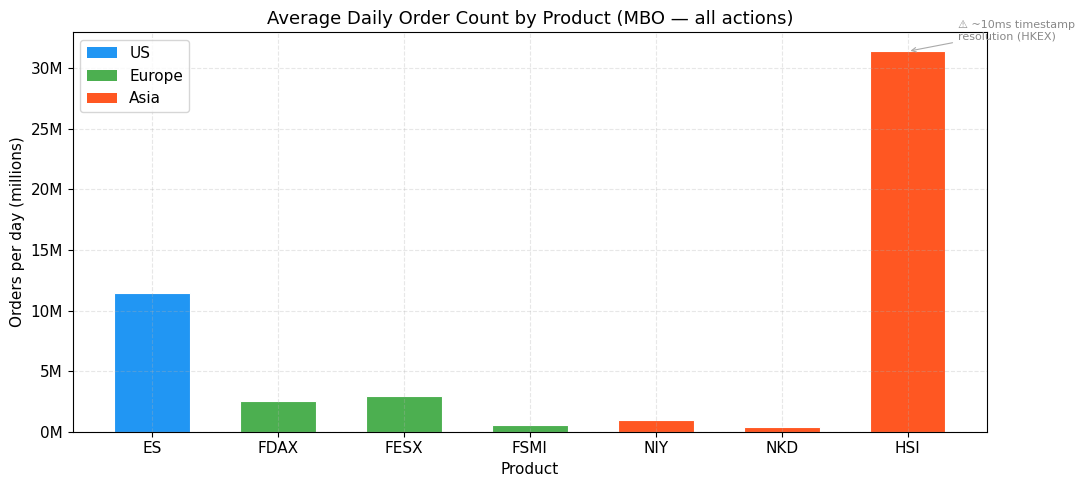

In [7]:
# ---------------------------------------------------------------------------
# Plot 1: Orders per day — bar chart grouped by zone
# HSI annotated with timestamp precision caveat
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5))

colors = [ZONE_COLORS[z] for z in stats_df["zone"]]
bars = ax.bar(
    stats_df["ticker"],
    stats_df["orders_per_day"] / 1e6,
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    width=0.6,
)

# Annotate HSI with timestamp caveat
hsi_idx = stats_df[stats_df["ticker"] == "HSI"].index
if len(hsi_idx):
    hsi_pos = stats_df.index.get_loc(hsi_idx[0])
    hsi_val = stats_df.loc[hsi_idx[0], "orders_per_day"] / 1e6
    ax.annotate(
        "⚠ ~10ms timestamp\nresolution (HKEX)",
        xy=(hsi_pos, hsi_val),
        xytext=(hsi_pos + 0.4, hsi_val + 1),
        fontsize=8,
        color="#888",
        arrowprops=dict(arrowstyle="->", color="#aaa", lw=0.8),
    )

# Legend for zones
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=z) for z, c in ZONE_COLORS.items()]
ax.legend(handles=legend_elements, loc="upper left", framealpha=0.8)

ax.set_title("Average Daily Order Count by Product (MBO — all actions)")
ax.set_ylabel("Orders per day (millions)")
ax.set_xlabel("Product")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}M"))

plt.tight_layout()
plt.savefig(destiny_research_folder / "reports/figures/orders_per_day.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Trades per Day by Product

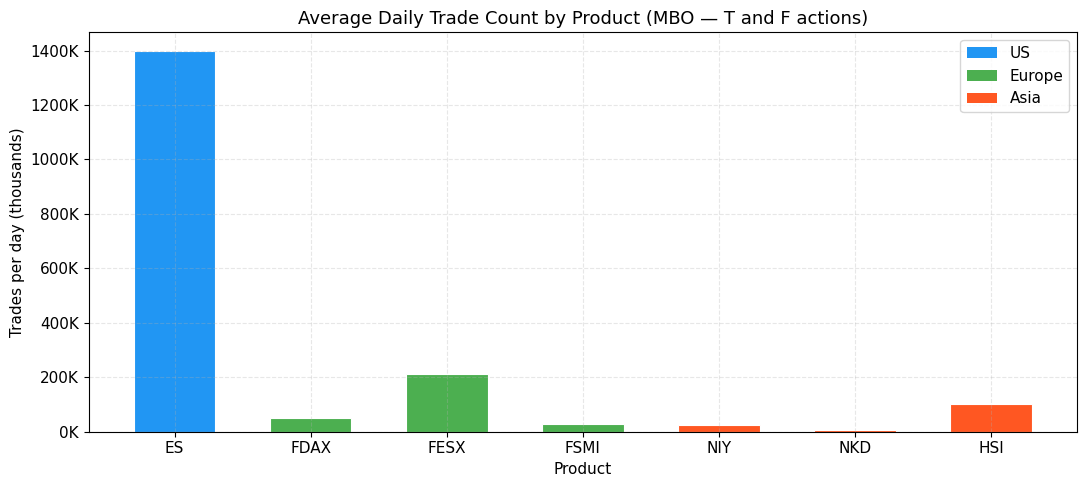

In [8]:
# ---------------------------------------------------------------------------
# Plot 2: Trades per day
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    stats_df["ticker"],
    stats_df["trades_per_day"] / 1e3,
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    width=0.6,
)

ax.legend(handles=legend_elements, loc="upper right", framealpha=0.8)
ax.set_title("Average Daily Trade Count by Product (MBO — T and F actions)")
ax.set_ylabel("Trades per day (thousands)")
ax.set_xlabel("Product")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}K"))

plt.tight_layout()
plt.savefig(destiny_research_folder / "reports/figures/trades_per_day.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Order-to-Trade Ratio (OTR)

The OTR is a first-order proxy for HFT intensity. A high ratio indicates that most orders are cancelled before execution — consistent with aggressive market-making, adverse selection avoidance, and quote stuffing behavior. A low ratio (ES at ~8x) indicates more directional, execution-driven order flow.

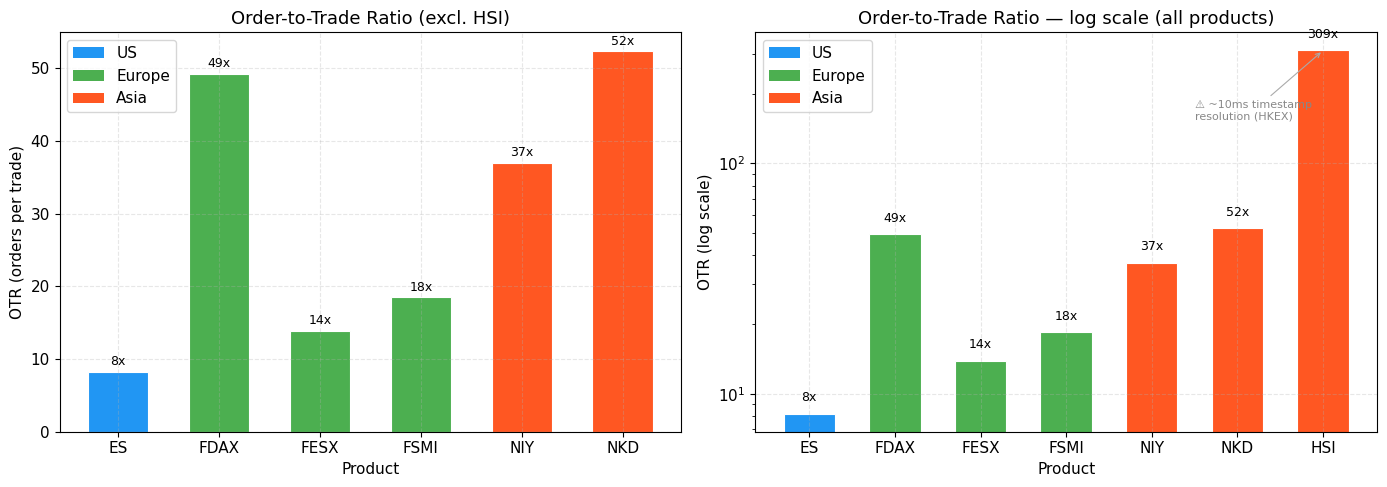

In [9]:
# ---------------------------------------------------------------------------
# Plot 3: Order-to-Trade Ratio — log scale (HSI at 580x would dwarf others)
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: linear scale (excluding HSI to show intra-market detail)
mask_no_hsi = stats_df["ticker"] != "HSI"
df_no_hsi   = stats_df[mask_no_hsi]
colors_no_hsi = [ZONE_COLORS[z] for z in df_no_hsi["zone"]]

axes[0].bar(
    df_no_hsi["ticker"],
    df_no_hsi["otr"],
    color=colors_no_hsi,
    edgecolor="white",
    linewidth=0.8,
    width=0.6,
)
for bar, val in zip(axes[0].patches, df_no_hsi["otr"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{val:.0f}x",
        ha="center", va="bottom", fontsize=9,
    )
axes[0].set_title("Order-to-Trade Ratio (excl. HSI)")
axes[0].set_ylabel("OTR (orders per trade)")
axes[0].set_xlabel("Product")
axes[0].legend(handles=legend_elements, loc="upper left", framealpha=0.8)

# Right: log scale — all products including HSI
axes[1].bar(
    stats_df["ticker"],
    stats_df["otr"],
    color=colors,
    edgecolor="white",
    linewidth=0.8,
    width=0.6,
)
axes[1].set_yscale("log")
for bar, val in zip(axes[1].patches, stats_df["otr"]):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 1.1,
        f"{val:.0f}x",
        ha="center", va="bottom", fontsize=9,
    )
axes[1].set_title("Order-to-Trade Ratio — log scale (all products)")
axes[1].set_ylabel("OTR (log scale)")
axes[1].set_xlabel("Product")
axes[1].legend(handles=legend_elements, loc="upper left", framealpha=0.8)

# HSI annotation
hsi_bar = [b for b, t in zip(axes[1].patches, stats_df["ticker"]) if t == "HSI"]
if hsi_bar:
    axes[1].annotate(
        "⚠ ~10ms timestamp\nresolution (HKEX)",
        xy=(hsi_bar[0].get_x() + hsi_bar[0].get_width() / 2, hsi_bar[0].get_height()),
        xytext=(hsi_bar[0].get_x() - 1.2, hsi_bar[0].get_height() * 0.5),
        fontsize=8,
        color="#888",
        arrowprops=dict(arrowstyle="->", color="#aaa", lw=0.8),
    )

plt.tight_layout()
plt.savefig(destiny_research_folder / "reports/figures/order_to_trade_ratio.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Summary Table

In [7]:
# ---------------------------------------------------------------------------
# Final summary table — formatted for presentation
# ---------------------------------------------------------------------------

summary = stats_df[[
    "ticker", "full_name", "zone", "currency", "source",
    "n_days", "orders_per_day", "trades_per_day", "otr"
]].copy()

summary.columns = [
    "Ticker", "Product", "Zone", "CCY", "Source",
    "Days", "Orders/Day", "Trades/Day", "OTR"
]

summary.style \
    .format({
        "Orders/Day": "{:,.0f}",
        "Trades/Day": "{:,.0f}",
        "OTR":        "{:.1f}x",
    }) \
    .set_caption("Cross-Market Microstructure Summary — Phase 1 (Destiny Research)") \
    .hide(axis="index")

Ticker,Product,Zone,CCY,Source,Days,Orders/Day,Trades/Day,OTR
ES,E-mini S&P 500,US,USD,Databento,27,"11,438,949","1,396,903",8.2x
FDAX,DAX Future,Europe,EUR,Databento,21,"2,533,734","51,527",49.2x
FESX,Euro Stoxx 50 Future,Europe,EUR,Databento,21,"2,945,974","211,818",13.9x
FSMI,SMI Future,Europe,CHF,Databento,21,"516,457","27,899",18.5x
NIY,Nikkei 225 Future (JPY),Asia,JPY,Databento,313,"961,486","25,972",37.0x
NKD,Nikkei 225 Future (USD),Asia,USD,Databento,313,"402,849","7,701",52.3x
HSI,Hang Seng Future,Asia,HKD,HKEX,20,"31,392,972","101,472",309.4x


## 5. Key Observations

**ES (US) — OTR ~8x**  
Lowest OTR in the universe. Most liquid futures market globally. Order flow is predominantly execution-driven — participants post with genuine fill intent. Minimal quote stuffing.

**FESX vs FDAX (Europe) — OTR 14x vs 49x**  
Counterintuitive: FESX (Euro Stoxx 50, pan-European benchmark) has a lower OTR than FDAX despite similar liquidity profiles. Suggests more directional participation on FESX and more intensive market-making quote activity on FDAX. To be investigated with cancel rate and fill rate decomposition.

**NIY vs NKD (Asia) — same underlying, different OTR**  
NIY (JPY-denominated, OSE) at 37x vs NKD (USD-denominated, CME) at 52x. NIY has 2.4x more orders/day and 3.4x more trades/day — liquidity is concentrated in the JPY leg. Price discovery likely leads on NIY. Lead-lag analysis planned.

**HSI (Asia) — OTR ~580x ⚠**  
Extreme outlier. Indicative of very high HFT market-making intensity with rapid add/cancel cycles (adverse selection avoidance). Note: HKEX timestamp resolution is ~10ms — sub-millisecond analysis is not reliable on this dataset. Cross-market comparisons involving HSI should use ≥10ms buckets.

---
*Next step — cancel_rate = n_cancels / n_adds and fill_rate = n_trades / n_adds per product per day, to decompose the OTR signal further.*